In [12]:
import sys
import os
sys.path.insert(0, '/home/olena/Git_repos/learning-pytorch/pytorch-CycleGAN-and-pix2pix')
os.chdir('/home/olena/Git_repos/learning-pytorch/pytorch-CycleGAN-and-pix2pix')
os.system('bash ./scripts/download_cyclegan_model.sh horse2zebra')
from models.networks import ResnetGenerator
from PIL import Image
from torchvision import transforms
import torch

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]


ПОПЕРЕДЖЕННЯ: використання часових позначок не працює з -O. Докладніші
відомості можна знайти на сторінці підручника (man).

--2026-06-23 22:01:01--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Визначення імені efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)… 128.32.244.190
Встановлення з'єднання з efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... з’єднано.
HTTP-запит надіслано, очікуємо на відповідь… 200 OK
Довжина: 45575747 (43M)
Зберігаємо до ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

     0K .......... .......... .......... .......... ..........  0%  122K 6m4s
    50K .......... .......... .......... .......... ..........  0%  249K 4m31s
   100K .......... .......... .......... .......... ..........  0%  239K 4m2s
   150K .......... .......... .......... .......... ..........  0% 24,7M 3m2s
   200K .......... .......... .......... .......... ..........  0%  245K 3m2s
   250K .......... .........

In [13]:
netG = ResnetGenerator(input_nc=3, output_nc=3, ngf=64)
netG.eval() 

ResnetGenerator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (8): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ResnetBlock(
      (conv_block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        

In [14]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

image = Image.open('/home/olena/Зображення/horse_man.jpg')
image_t = preprocess(image)
batch = torch.unsqueeze(image_t, 0)

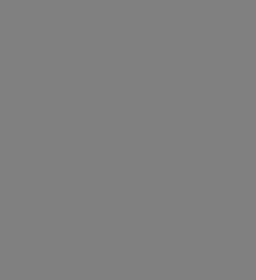

In [15]:
output = netG(batch)
out_t = (output.data.squeeze() + 1) / 2.0 #output.data - чистые данные из тензора(без градиентов), squeeze() уберает размерность 1 (т.е. батч),
                                          #+ 1) / 2.0 изменяют значения из [-1, 1] к [0, 1] (понятный для пайтона) 
out_img = transforms.ToPILImage()(out_t) #значения пикселей автоматически переводятся в привычный диапазон от 0 до 255
out_img.save('/home/olena/Зображення/zebra.jpg')
out_img